# Large-Scale Dataset Analysis: 250K Job Records

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../Dataset/original_dataset.csv')

This dataset is under Creative Commons CC0 (Public Domain Dedication).

## I. Data cleaning, memory optimization and validation

In [3]:
df.head(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


In the previous cell, we used `df.head(10)` to display the first 10 rows of the DataFrame.
This allows us to quickly inspect the structure of the data.

### I-1. 📊 Data Structure & Technical Audit

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.7 MB


A technical inspection of the 250,000 records using df.info() reveals the following:

- Data Integrity  
  The dataset is fully complete with no missing values, meaning no imputation is required at this stage.

- Feature Types  
  The dataset includes 4 numerical columns (e.g., salary, experience_years) correctly stored as int64, and 6 categorical columns currently represented as strings.

- Memory Optimization  
  The dataset currently uses approximately 30.7 MB of memory.  
  To improve efficiency, high-frequency string columns such as industry, education_level, and remote_work will be converted to the category data type, reducing memory usage.

### I-2. 🔍 Categorical Values Validation (Data Integrity Check)

In [5]:
text_cols = df.select_dtypes(include=['object', 'str']).columns
for col in text_cols:
    print(f"--- Unique values in {col} ---")
    print(df[col].unique())
    print("\n")

--- Unique values in job_title ---
<ArrowStringArray>
[              'AI Engineer',              'Data Analyst',
        'Frontend Developer',          'Business Analyst',
           'Product Manager',         'Backend Developer',
 'Machine Learning Engineer',           'DevOps Engineer',
         'Software Engineer',     'Cybersecurity Analyst',
            'Data Scientist',            'Cloud Engineer']
Length: 12, dtype: str


--- Unique values in education_level ---
<ArrowStringArray>
['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Length: 5, dtype: str


--- Unique values in industry ---
<ArrowStringArray>
[   'Healthcare',       'Telecom',         'Media',        'Retail',
 'Manufacturing',     'Education',       'Finance',    'Technology',
    'Consulting',    'Government']
Length: 10, dtype: str


--- Unique values in company_size ---
<ArrowStringArray>
['Medium', 'Small', 'Large', 'Enterprise', 'Startup']
Length: 5, dtype: str


--- Unique values in location ---
<ArrowS

After performing a deep dive into the unique values of each categorical column, we have verified the following:
1. Data Consistency & Cleaning Quality

    No Redundancy: There are no duplicate categories written in different styles (e.g., "Remote" and "remote" are not present; only one consistent format exists).

    No Whitespace Issues: All string values are "trimmed" and clean; there are no leading or trailing spaces 


    Status: ✅ Production-Ready

    Conclusion: Everything is perfectly aligned. The categories are logical, standardized, and clean, providing a robust foundation for the next stage of statistical analysis and visualization.

### I-3. 📈 Statistical Summary & Sanity Check

In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


Through the analysis of Descriptive Statistics for numerical features:

 -   Range: Salaries range from $31,867 (Minimum) to $333,046 (Maximum). 

- There are no "impossible" values (such as negative salaries, 1000 years of experience, or millions of certificates).

   **Status ⚠️ : There is still an underlying issue that we will address in the section: I-7. 🤔Beyond the Numbers: How Realistic is this Salary Data**

### I-4. 💾 Initial Memory Consumption (Pre-Optimization)

In [7]:
print(df.memory_usage(deep=True))

Index                   132
job_title           6061551
experience_years    2000000
education_level     3750430
skills_count        2000000
industry            4174893
company_size        3648620
location            3600551
remote_work         2916807
certifications      2000000
salary              2000000
dtype: int64



Before applying any data type transitions, we inspected the memory footprint of the DataFrame using df.memory_usage(deep=True).
1. Analysis of Current State

    Heavyweight Columns: The text-based columns (stored as object) are consuming the most memory. For example:

        job_title: ~6.06 MB

        industry: ~4.17 MB

        education_level: ~3.75 MB


2. Technical Observation

    Status: ⚠️ Pre-Optimization Phase

    Issue: Storing repetitive strings as "Objects" is inefficient. Each entry is being stored as a full string pointer, which scales poorly as the dataset grows.

    Observation: The total memory usage is dominated by these categorical strings, which are prime candidates for optimization.

3. Transition Goal

This baseline measurement serves as our Control Group. In the next step, we will convert these 6 string columns to the category type to observe the drastic reduction in memory overhead.

### I-5. ⚙️ Data Type Transformation (Memory Optimization)

In [8]:
df['job_title'] = df['job_title'].astype('category')
df['education_level'] = df['education_level'].astype('category')
df['industry'] = df['industry'].astype('category')
df['company_size'] = df['company_size'].astype('category')
df['location'] = df['location'].astype('category')
df['remote_work'] = df['remote_work'].astype('category')


In this step, we executed a strategic conversion of categorical features to enhance performance and reduce memory overhead.
1. The Engineering Action

We identified 6 columns originally stored as generic Strings (Objects) and explicitly cast them to the category data type:

    job_title, education_level, industry, company_size, location, and remote_work.

2. Why Category over String?

    Storage Efficiency: Instead of storing the full text for each of the 250,000 rows, Pandas now stores a unique integer key for each category, mapping it to the original string in a small lookup table.

    Computational Speed: Operations such as sorting, grouping, and unique value counting are now significantly faster as they operate on integers "under the hood."


In [9]:
print(df.memory_usage(deep=True))

Index                   132
job_title            250293
experience_years    2000000
education_level      250076
skills_count        2000000
industry             250169
company_size         250074
location             250146
remote_work          250036
certifications      2000000
salary              2000000
dtype: int64


 Status: ✅ Optimized

    Result: The data remains logically identical, but the internal representation is now optimized for large-scale data analysis and machine learning workflows.

In [10]:
## df.to_parquet('jobs_data_optimized.parquet')

After optimizing the data types and verifying the integrity of the 250,000 records, we exported the final DataFrame to a Parquet file format.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   job_title         250000 non-null  category
 1   experience_years  250000 non-null  int64   
 2   education_level   250000 non-null  category
 3   skills_count      250000 non-null  int64   
 4   industry          250000 non-null  category
 5   company_size      250000 non-null  category
 6   location          250000 non-null  category
 7   remote_work       250000 non-null  category
 8   certifications    250000 non-null  int64   
 9   salary            250000 non-null  int64   
dtypes: category(6), int64(4)
memory usage: 9.1 MB


### I-6. 📉  Optimization Results



After converting the string-based columns to the category data type, we re-inspected the DataFrame structure to quantify the performance gains.
1. Key Observations

    Data Type Update: All 6 target columns (job_title, education_level, etc.) are now successfully recognized as category instead of object.

2. Memory Usage Impact

    Initial Memory: ~30.7 MB

    Optimized Memory: 9.1 MB

    Efficiency Gain: We achieved a ~70% reduction in memory footprint.

3. Why this matters for Scalability

By reducing the memory usage to less than a third of its original size, we have:

    Faster Computations: Operations like df.groupby() or df.pivot_table() will now run much faster because they process integer codes instead of raw strings.


### I-7. 🤔Beyond the Numbers: How Realistic is this Salary Data

In [12]:
office_based_df = df[df['remote_work'] == 'No']

job_location_median = office_based_df.pivot_table(
    index='job_title', 
    columns='location', 
    values='salary', 
    aggfunc='median'
).fillna(0)

print("Median Salaries by Job Title and Location (Office-Based Only):")
display(job_location_median)

Median Salaries by Job Title and Location (Office-Based Only):


location,Australia,Canada,Germany,India,Netherlands,Remote,Singapore,Sweden,UK,USA
job_title,,,,,,,,,,
AI Engineer,160215.0,192125.0,181225.0,112848.0,164525.0,162693.0,158868.0,162783.0,185974.0,211324.0
Backend Developer,130423.5,157828.0,141210.0,90420.5,129058.0,129841.0,128358.0,129308.0,149664.0,170533.0
Business Analyst,114531.5,134063.5,127232.0,79181.0,114380.0,112881.0,113750.0,114907.5,133038.0,146194.0
Cloud Engineer,141148.0,169855.0,155653.0,98713.0,142053.0,142386.0,144156.5,142248.0,161609.0,185816.0
Cybersecurity Analyst,140484.0,166226.0,151249.0,95770.0,137450.5,138998.5,138872.0,139495.0,159397.0,183884.5
Data Analyst,110535.0,133458.0,122220.0,78205.5,112271.0,111394.0,110897.0,111186.0,130915.0,147261.0
Data Scientist,136338.5,164743.0,150207.0,95579.0,136546.0,137947.0,137920.0,135681.0,159105.0,178626.0
DevOps Engineer,140830.0,167385.0,155249.0,98638.0,140120.5,141713.0,139578.5,140751.0,162482.0,181742.0
Frontend Developer,123114.0,148758.0,135843.5,87090.0,122473.0,124232.0,125362.5,123380.0,142595.0,164401.0


This table illustrates the Median Salary per country and job title for office-based roles **(Remote Work = No)**.

Let’s take India as a sample from this table. The median salary shown for India does not seem to reflect reality; however, this could be due to a small sample size, which can often be misleading. Let's verify:

In [13]:
office_based_df = df[df['remote_work'] == 'No']

job_location_count = office_based_df.pivot_table(
    index='job_title', 
    columns='location', 
    values='salary', 
    aggfunc='count'
).fillna(0)

print("Sample Size (Count) per Job and Location (Office-Based Only):")
display(job_location_count)

Sample Size (Count) per Job and Location (Office-Based Only):


location,Australia,Canada,Germany,India,Netherlands,Remote,Singapore,Sweden,UK,USA
job_title,,,,,,,,,,
AI Engineer,672,715,662,689,689,672,710,668,693,732
Backend Developer,704,677,745,712,698,680,671,702,681,695
Business Analyst,720,692,731,691,663,632,667,712,716,659
Cloud Engineer,670,707,705,667,675,642,714,681,704,731
Cybersecurity Analyst,735,697,729,753,684,702,693,712,675,664
Data Analyst,677,705,697,744,693,713,701,670,709,678
Data Scientist,728,711,685,659,692,711,688,702,635,695
DevOps Engineer,717,711,688,691,712,692,718,695,729,696
Frontend Developer,711,691,684,707,709,671,696,698,686,669


This table displays the sample size (count) of salary records per country and job title for office-based roles (Remote Work = No).

Upon observation, we have a sufficient sample size for job roles in India. Therefore, the unrealistic median salary is not because to a lack of data points. Instead, this suggests two possibilities:

    - Selection Bias: The dataset may have been sampled from specific high-paying tiers 

    - Synthetic Nature: The data might be synthetic (artificial) and not reflective of real-world labor market conditions.

<div style="padding: 15px; background-color: #ffe6e6; border-left: 5px solid #ff4d4d; border-radius: 5px;">
    <h3 style="color: #cc0000; margin-top: 0;">⚠️ Critical Observation: Logical Data Conflict</h3>
    <p style="color: #333;">
        Even after filtering the dataset for office-based roles <b>remote_work = No</b>, a significant number of records still list "Remote" as their physical location.
       This represents a logical inconsistency in the data. Which further confirms that this dataset may be synthetic
    </p>
</div>

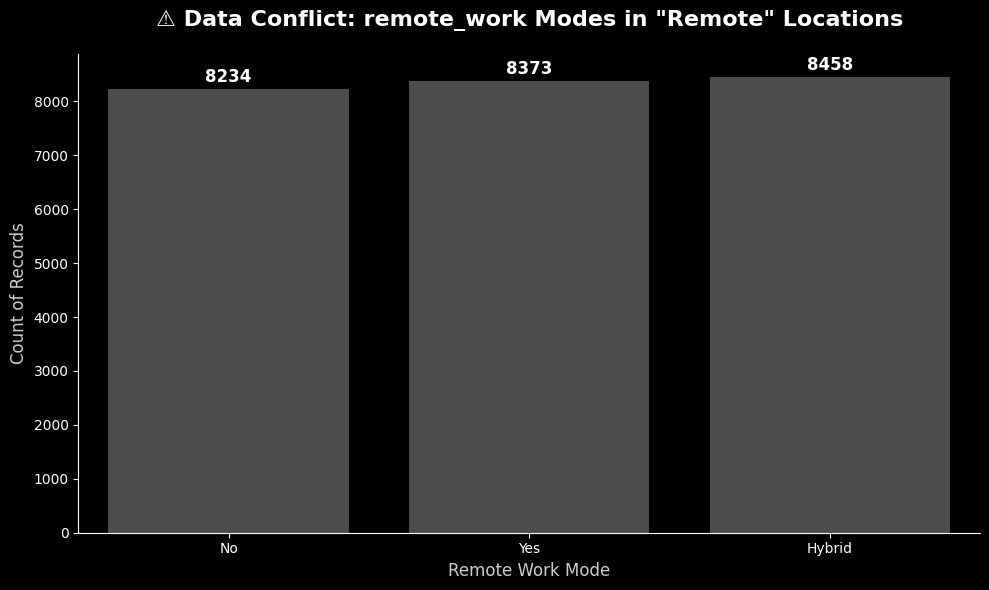

In [14]:

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

remote_location_df = df[df['location'] == 'Remote']
remote_work_counts = remote_location_df['remote_work'].value_counts().reindex(['No', 'Yes', 'Hybrid'], fill_value=0)

ax = sns.barplot(x=remote_work_counts.index, y=remote_work_counts.values,color="#fff", alpha=0.3)

plt.title('⚠️ Data Conflict: remote_work Modes in "Remote" Locations', 
          fontsize=16, fontweight='bold', color='#ffffff', pad=20)
plt.xlabel('Remote Work Mode', fontsize=12, color='#cccccc')
plt.ylabel('Count of Records', fontsize=12, color='#cccccc')

sns.despine()

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=12, fontweight='bold', color='white', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [15]:
%%html
<div style="padding: 20px; 
            background-color: #1a1a1a; 
            border-left: 6px solid #ff4d4d; 
            border-radius: 8px; 
            color: #ffffff; 
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
            
    <h3 style="color: #ff4d4d; margin-top: 0; display: flex; align-items: center;">
        <span style="margin-right: 10px;">⚠️</span> Critical Alert
    </h3>
    
    <p style="font-size: 1.1em; line-height: 1.6; margin-bottom: 10px;">
        As this graph illustrates, there is a clear <b>inconsistency</b>: many records labeled as 
        <span style="color: #00ffcc; font-family: monospace;">"Remote"</span> in the location column are 
        simultaneously categorized as <span style="color: #ffcc00; font-family: monospace;">"No"</span> 
        for remote work.
    </p>
    
    <p style="font-size: 1.1em; line-height: 1.6; margin-bottom: 10px;">
        This confirms a <b>logical discrepancy</b> in the data, strongly suggesting that the dataset is 
        <span style="text-decoration: underline; color: #ff4d4d;">synthetic or artificially generated</span>.
    </p>
    
    <hr style="border: 0; border-top: 1px solid #444; margin: 15px 0;">
    

</div>

### I-8. 📑Data Validation

In [16]:
%%html
<div style="padding: 15px; 
            background-color: #f8f9fa; 
            border-left: 5px solid #2ecc71; 
            border-radius: 5px; 
            color: #2c3e50; 
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
            
    <h4 style="color: #27ae60; margin-top: 0;">📘 Methodological Note: Numerical Scope & Potential Bias</h4>
    
    <p style="font-size: 1em; line-height: 1.5;">
        In this analysis, we treat the data as <b>pure numerical values</b> within the scope of this specific dataset. It is crucial to acknowledge that direct cross-country comparisons may be misleading due to <b>uncontrolled variables</b>.
    </p>
    
    <p style="font-size: 0.95em; line-height: 1.5; color: #34495e;">
        <i>Example:</i> We might have a country with a high average salary where most of the data pertains to high school diplomas, while a country with a low average salary where most of the data pertains to doctorates.

        This might not apply to these data points, but it's just an example.
    </p>
    
    <hr style="border: 0; border-top: 1px solid #ddd; margin: 10px 0;">
    
</div>

## II. Exploratory Data Analysis (EDA)

### II-1. Correlation Analysis: Years of Experience vs. Annual Salary

#### I-1-1. Comprehensive Salary Mapping: A 250K-Record Scatter Analysis by years of experience

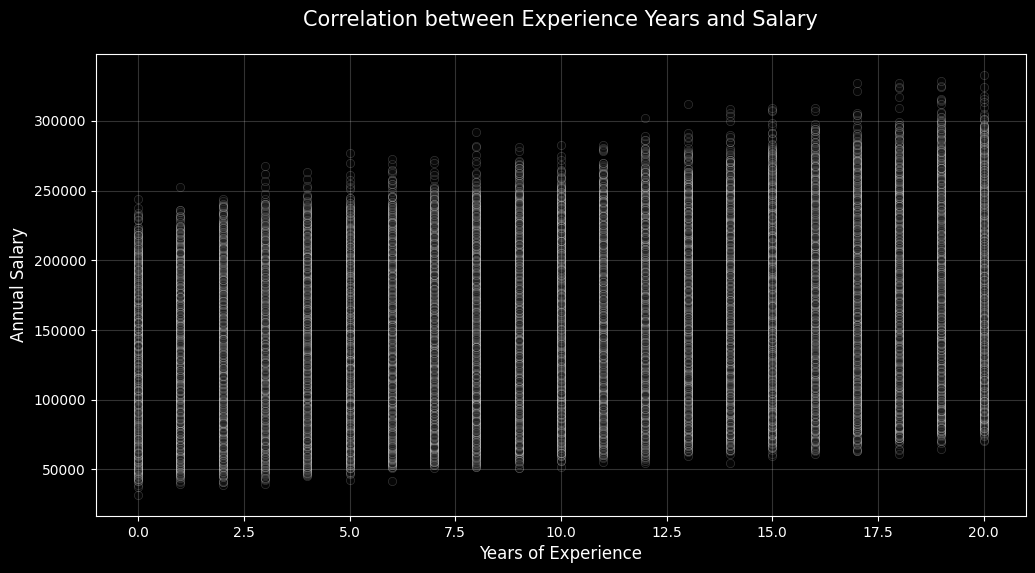

In [17]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x='experience_years', y='salary', alpha=0.2, color='#222')

plt.title('Correlation between Experience Years and Salary', fontsize=15, pad=20)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Annual Salary', fontsize=12)

plt.grid(True, alpha=0.2)
plt.show()

Based on the visualized 250,000 records in Correlation between Experience Years and Salary scatter plot, we can observe the following:

  -  Upward Trend in Max and Min Salaries: There is a clear positive correlation where an increase in Years of Experience leads to a consistent rise in both the Minimum and Maximum salary levels within the dataset.

  -   Shift in Density Concentration: While the overall range expands, we observe that the highest density of points (the darkest areas in the plot) gradually shifts upward as experience increases. This indicates that the "market standard" for a typical salary moves to a higher baseline with seniority.

  -  Salary Overlap: The data shows that certain individuals with fewer years of experience earn higher salaries than others with significantly more seniority, suggesting that other factors (skills,industry or country) play a major role.

  - Next Step: To gain a clearer understanding of the typical career progression, we will conduct a comparison of Median Salaries across all years of experience in the data.

#### II-1-2. Median Salary Growth over Years of Experience

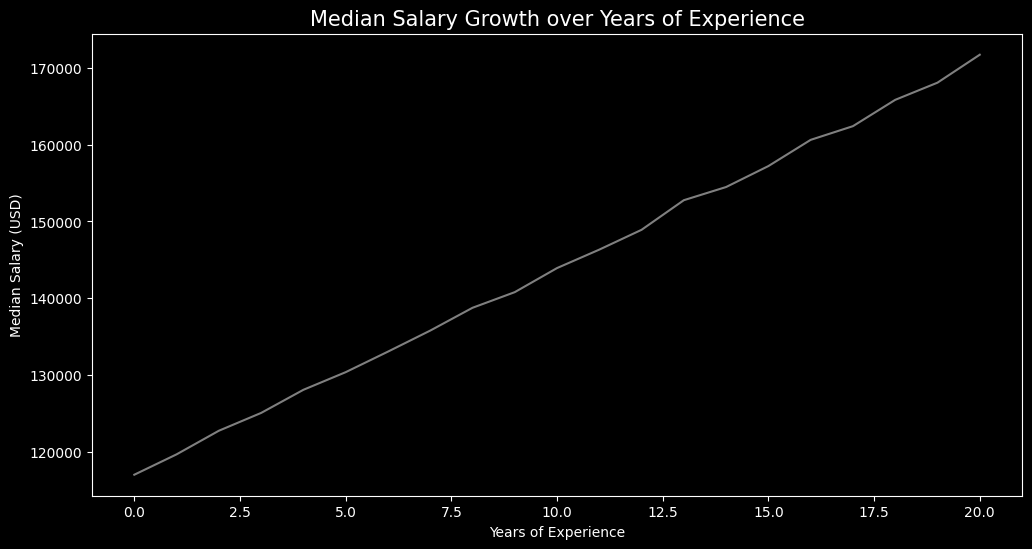

In [18]:

plt.style.use('dark_background')
plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='experience_years', y='salary', estimator=np.median, errorbar=None, color='#fff', alpha=0.5)

plt.title('Median Salary Growth over Years of Experience', fontsize=15)
plt.xlabel('Years of Experience')
plt.ylabel('Median Salary (USD)')

plt.show()

Based on the Median Salary Growth over Years of Experience plot, we can observe the following:


    Consistent Median Increase: There is a clear and steady upward trend in the median salary as years of experience increase.

#### II-1-3. Year-over-Year Salary Growth: Absolute and Percentage Analysis

In [19]:
median_salaries = df.groupby('experience_years')['salary'].median()

distinct_experience = sorted(df['experience_years'].unique())
print("Distinct Experience Years:", distinct_experience)

print("-" *30)

is_consecutive = (median_salaries.index.to_series().diff().dropna() == 1).all()
print(f"Are years consecutive? {is_consecutive}")

print("-" * 30)

print(df['experience_years'].value_counts().sort_index())

Distinct Experience Years: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
------------------------------
Are years consecutive? True
------------------------------
experience_years
0     11804
1     12011
2     11950
3     11890
4     12001
5     11862
6     11860
7     11981
8     11822
9     11856
10    11777
11    11747
12    11944
13    11699
14    12166
15    12052
16    11908
17    11735
18    12102
19    11875
20    11958
Name: count, dtype: int64



Before proceeding with the Year-over-Year growth analysis, it is crucial to validate the structure and volume of our data to ensure the mathematical results are both accurate and representative.
1. Why check for Consecutive Years?

    Mathematical Accuracy: To calculate the Yearly Increase and Growth Rate (%) using methods like .diff() and .pct_change(), the years of experience must be consecutive (e.g., 0, 1, 2...).

    The Logic: If a year is missing (e.g., jumping from 5 to 7 years), the calculation would incorrectly show a 2-year jump as a 1-year annual increase. By confirming that is_consecutive is True, we ensure our growth metrics reflect actual annual changes.

2. Why check Value Counts per Year?

    Statistical Significance: With a massive dataset of 250,000 records, we need to ensure that each "year of experience" category has a sufficient number of observations.

    Reliability of the Median: A median calculated from 10,000 people is much more "stable" and "trustworthy" than a median calculated from only 10 or 20 people. Checking the value_counts() allows us to identify if certain seniority levels have enough data to be considered a reliable market standard.

In [20]:
yearly_increase = median_salaries.diff()
percentage_growth = median_salaries.pct_change() * 100
intervals = [f"{int(i-1)}-{int(i)}" for i in median_salaries.index[1:]]

growth_report = pd.DataFrame({
    'Experience Gap': intervals,
    'Annual Increase': yearly_increase.iloc[1:].values,
    'Growth Rate (%)': percentage_growth.iloc[1:].values
})

print(growth_report)

   Experience Gap  Annual Increase  Growth Rate (%)
0             0-1           2652.5         2.266774
1             1-2           3075.5         2.570006
2             2-3           2319.0         1.889290
3             3-4           3012.5         2.408776
4             4-5           2295.5         1.792295
5             5-6           2676.0         2.052596
6             6-7           2739.5         2.059039
7             7-8           2969.0         2.186513
8             8-9           2038.0         1.468765
9            9-10           3136.0         2.227368
10          10-11           2404.0         1.670256
11          11-12           2581.0         1.763773
12          12-13           3856.0         2.589397
13          13-14           1716.0         1.123250
14          14-15           2727.5         1.765521
15          15-16           3414.5         2.171873
16          16-17           1784.0         1.110634
17          17-18           3426.5         2.109745
18          

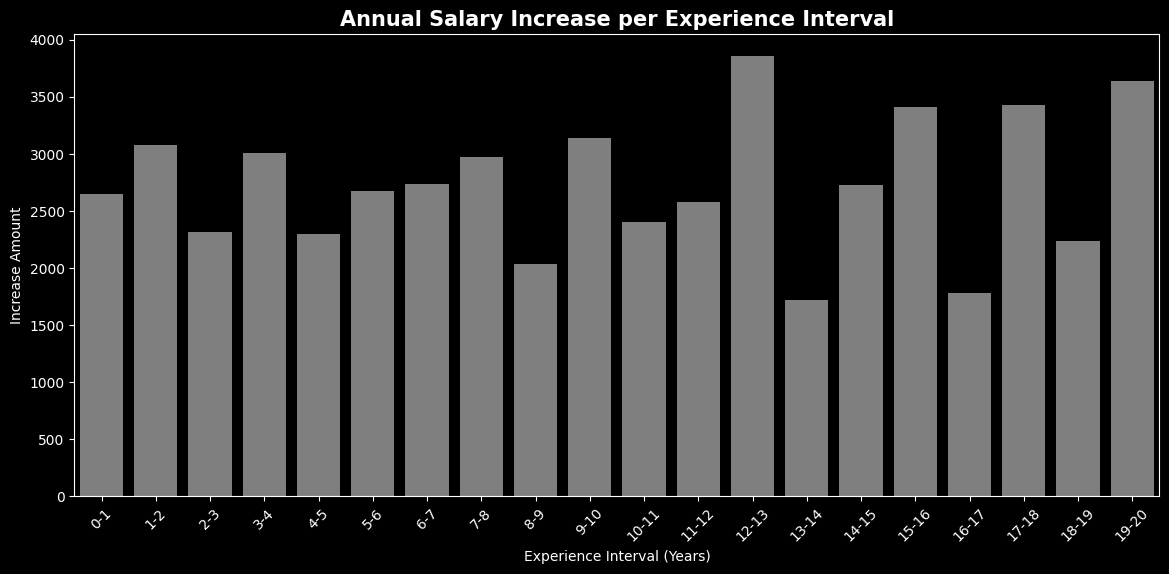

In [21]:
plt.figure(figsize=(14, 6))

sns.barplot(data=growth_report, x='Experience Gap', y='Annual Increase', color="#fff", alpha=0.5)

plt.title('Annual Salary Increase per Experience Interval', fontsize=15, fontweight='bold')
plt.xlabel('Experience Interval (Years)')
plt.ylabel('Increase Amount')
plt.xticks(rotation=45) 
plt.show()

From Annual Salary Increase ($) per Experience Interval bar chart:

**Volatility in Growth**: The annual salary increase does not follow a predictable linear path, showing significant fluctuation between years.

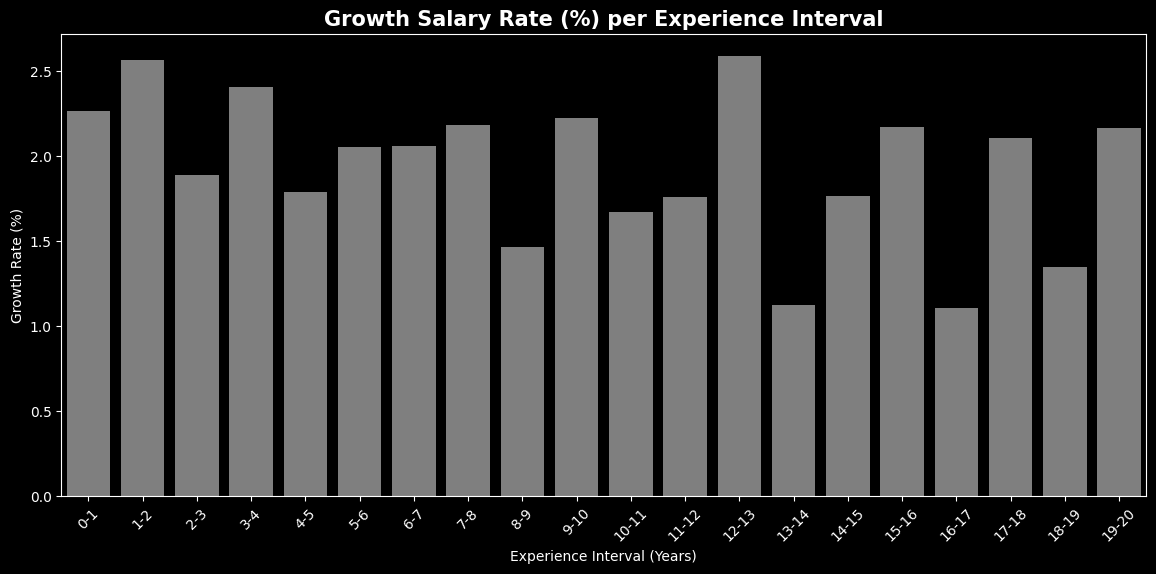

In [22]:
plt.figure(figsize=(14, 6))

sns.barplot(data=growth_report, x='Experience Gap', y='Growth Rate (%)',color='#fff',alpha=0.5)

plt.title('Growth Salary Rate (%) per Experience Interval', fontsize=15, fontweight='bold')
plt.xlabel('Experience Interval (Years)')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=45) 
plt.show()

**Volatility in Growth:** 

The annual salary growth rate does not follow a predictable linear path, showing significant fluctuations across experience intervals.

#### II-1-4. Standard Deviation Trend: Growing Salary Volatility

In [23]:
std_by_year = df.groupby('experience_years')['salary'].std()

target_years = [1, 5, 10, 15, 20]
target_std = std_by_year.loc[target_years]

std_report = target_std.reset_index()
std_report.columns = ['Years of Experience', 'Standard Deviation']
print(std_report)

   Years of Experience  Standard Deviation
0                    1        30178.353663
1                    5        31189.351867
2                   10        33349.987461
3                   15        35622.615018
4                   20        37934.873519


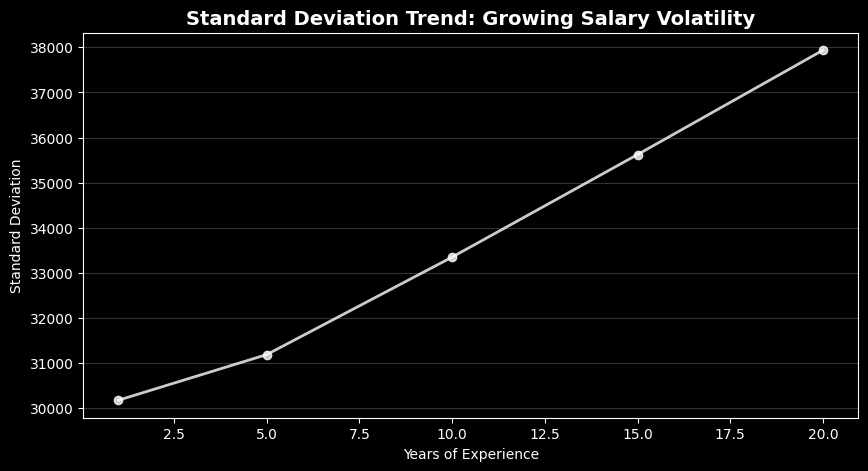

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(std_report['Years of Experience'], std_report['Standard Deviation'], 
         marker='o', color='#fff', alpha=0.8, linewidth=2)

plt.title('Standard Deviation Trend: Growing Salary Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Standard Deviation')
plt.grid(axis='y', alpha=0.2)
plt.show()

**Technical Analysis: Standard Deviation as an Indicator of Market Volatility**

Linear Development of Risk: Standard deviation follows a consistently upward linear path. This indicates a structural shift in the market as professionals gain more experience.

Prediction vs. Variance: In the early stages of a career (first year), a low standard deviation (around 30,000) suggests a more uniform salary scale compared to those with more years of experience. However, by year 20, the variance widens to approximately $38,000, demonstrating that more years of experience lead to greater salary variance.


**Results Interpretation: From Standardization to Divergence**

The linear growth of Standard Deviation alongside increasing Salary Variance leads to several key insights:


-  As careers mature, Seniority does not guarantee a high salary; rather, it expands the potential range, meaning the gap between top performers and the median wider significantly over time.

-  Market Maturity: The rising variance proves that the industry rewards long-term specialization disproportionately. Tenure acts as a "multiplier" for those who successfully position themselves in high-demand sub-sectors, creating the "Outliers" seen in the 300k+ range.

#### II-1-5. Salary Comparison by Experience and Remote Work Status

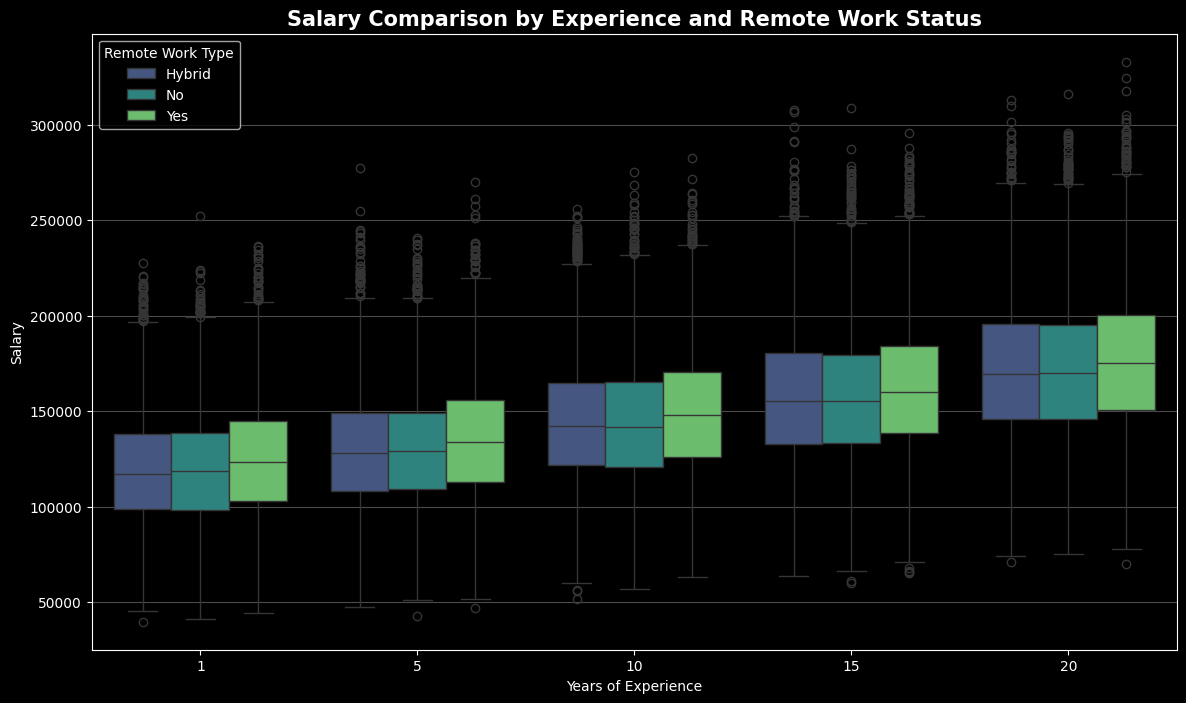

In [25]:

years_to_show = [1, 5, 10, 15, 20]
df_filtered = df[df['experience_years'].isin(years_to_show)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_filtered, x='experience_years', y='salary', hue='remote_work', 
            palette='viridis', showfliers=True)

plt.title('Salary Comparison by Experience and Remote Work Status', fontsize=15, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(title='Remote Work Type')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Analysis: The Impact of Remote Work on Salary Trajectory**

    Remote Work Advantage: Across all experience levels, fully remote roles  consistently outperform Hybrid and In-person roles in terms of median salary.


    Market Standard: Hybrid and Non-remote roles show similar salary distributions, suggesting that the primary market distinction is between "Fully Remote" vs. "Office-Affiliated" roles.

### II-2. Analyzing the Correlation of Education Level with Salary

#### II-2-1. Median Salary by Education Level

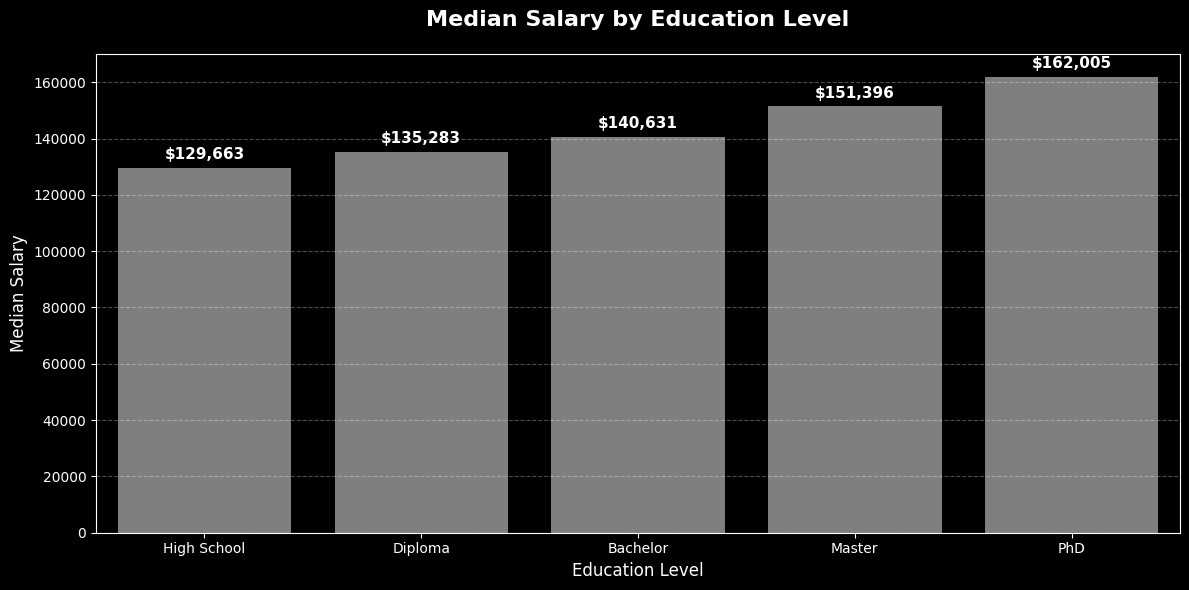

In [26]:
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='education_level', 
    y='salary', 
    order=education_order, 
    estimator='median',  
    errorbar=None,
    color="#fff",
    alpha=0.5
)

plt.title('Median Salary by Education Level', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Median Salary', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

medians = df.groupby('education_level')['salary'].median().loc[education_order]
for i, value in enumerate(medians):
    plt.text(i, value + 2000, f'${int(value):,}', ha='center', va='bottom', fontweight='bold', fontsize=11)


plt.tight_layout()
plt.show()

**Consistent Growth:**

- There is a clear linear progression where higher education levels directly correlate with increased median salaries.
- PhD Dominance: PhD holders command the highest median salary (162,005)
- Educational Floor: The relatively high baseline for High School graduates indicates a lucrative industry

#### II-2-2. Salary Distribution & Variance Across Education Levels

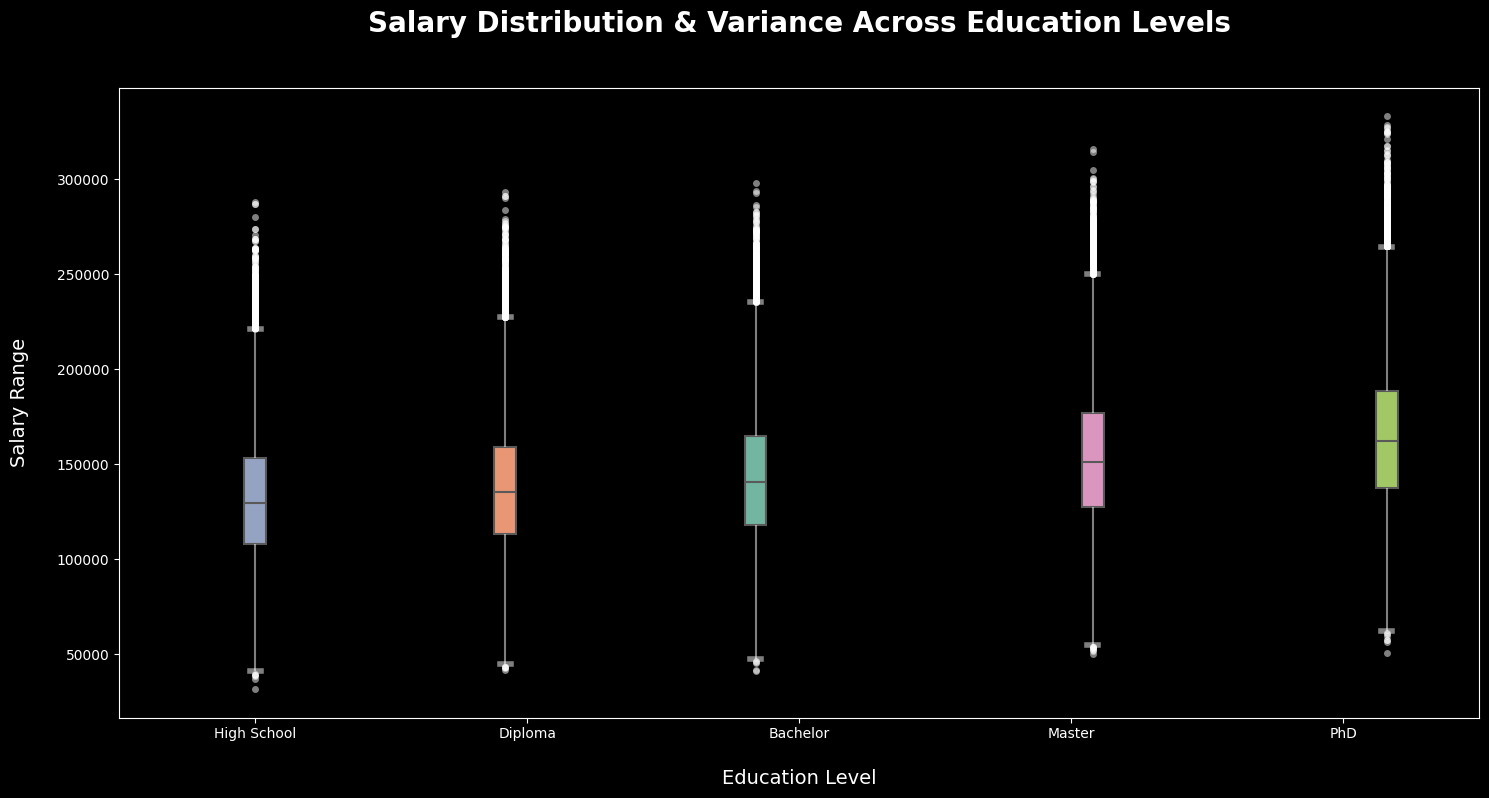

In [27]:

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(16, 9))

education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']

sns.boxplot(
    data=df, 
    x='education_level', 
    y='salary', 
    order=education_order, 
    hue='education_level', 
    palette='Set2', 
    legend=False, 
    linewidth=1.5,
    width=0.4,
    ax=ax,
    flierprops={
        'marker': 'o',          
        'markersize': 5,        
        'markerfacecolor': 'auto', 
        'markeredgecolor': 'none',
        'alpha': 0.5
    },
    whiskerprops={'color': '#ffffff', 'linewidth': 1.5, 'alpha': 0.5},
    capprops={'color': '#ffffff', 'linewidth': 4, 'alpha': 0.5}
)

ax.set_title('Salary Distribution & Variance Across Education Levels', 
             fontsize=20, fontweight='bold', pad=40)

ax.set_xlabel('Education Level', fontsize=14, labelpad=20)
ax.set_ylabel('Salary Range', fontsize=14, labelpad=20)


plt.subplots_adjust(top=0.85, bottom=0.15, left=0.1, right=0.95)

plt.show()

This box chart provides a comprehensive statistical overview of how wages relate to academic qualifications. It reveals the full picture beyond simple averages, focusing on volatility, outliers, and the minimum income threshold.

1. **The “Minimum Income” Effect**

There is a clear direct correlation between educational level and minimum wage.

The bottom lines of the rectangle (representing the lowest 25% of earners) rise steadily from high school to doctorate.

2. **Significant Overlap Between Quartiles**

Despite the high median, there is significant overlap between the boxes (the middle half of the data).

A high school graduate can earn more than someone with a doctorate for several reasons.

Academic qualifications are not the sole determinant of salary. Factors such as specialized skills, years of experience, country, and others also influence pay.

#### II-2-3. The Interplay between Education & Experience on Compensation

In [28]:
pivot_df = df.pivot_table(
    index='education_level', 
    columns='experience_years', 
    values='salary', 
    aggfunc='median'
).reindex(['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'])

In [29]:
pivot_df

experience_years,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
education_level,,,,,,,,,,,,,,,,,,,,,
High School,103883.0,105300.5,109081.0,111767.0,114254.0,115870.5,119501.0,122267.0,124018.5,128042.0,...,132917.0,135371.0,138250.0,141736.5,143787.0,146681.0,150445.0,152088.5,155379.0,158037.0
Diploma,110234.0,111650.0,114102.5,116739.5,119975.0,122045.5,125699.0,127996.0,131219.0,132084.5,...,138634.0,141191.0,143765.0,146039.5,148615.5,151621.0,153336.0,157897.5,158973.0,163682.5
Bachelor,114488.0,116437.0,119379.0,121898.5,125598.0,127560.0,130586.0,132607.0,136177.0,138148.0,...,144399.0,145329.0,149372.0,150806.0,154802.0,156836.5,159636.5,163772.5,165023.0,168131.0
Master,123970.0,126304.0,131129.5,131908.0,135940.0,138488.0,140984.0,142215.0,146833.0,149764.5,...,153958.0,156622.0,162017.5,163025.0,165446.0,167741.5,169811.0,172587.0,175570.0,180244.0
PhD,136343.5,138009.0,141528.0,143979.0,145207.0,147817.0,152277.5,156404.0,157563.0,158649.0,...,165224.0,167226.0,169449.0,173101.0,175144.5,179785.0,179972.0,183599.0,187581.0,191260.5


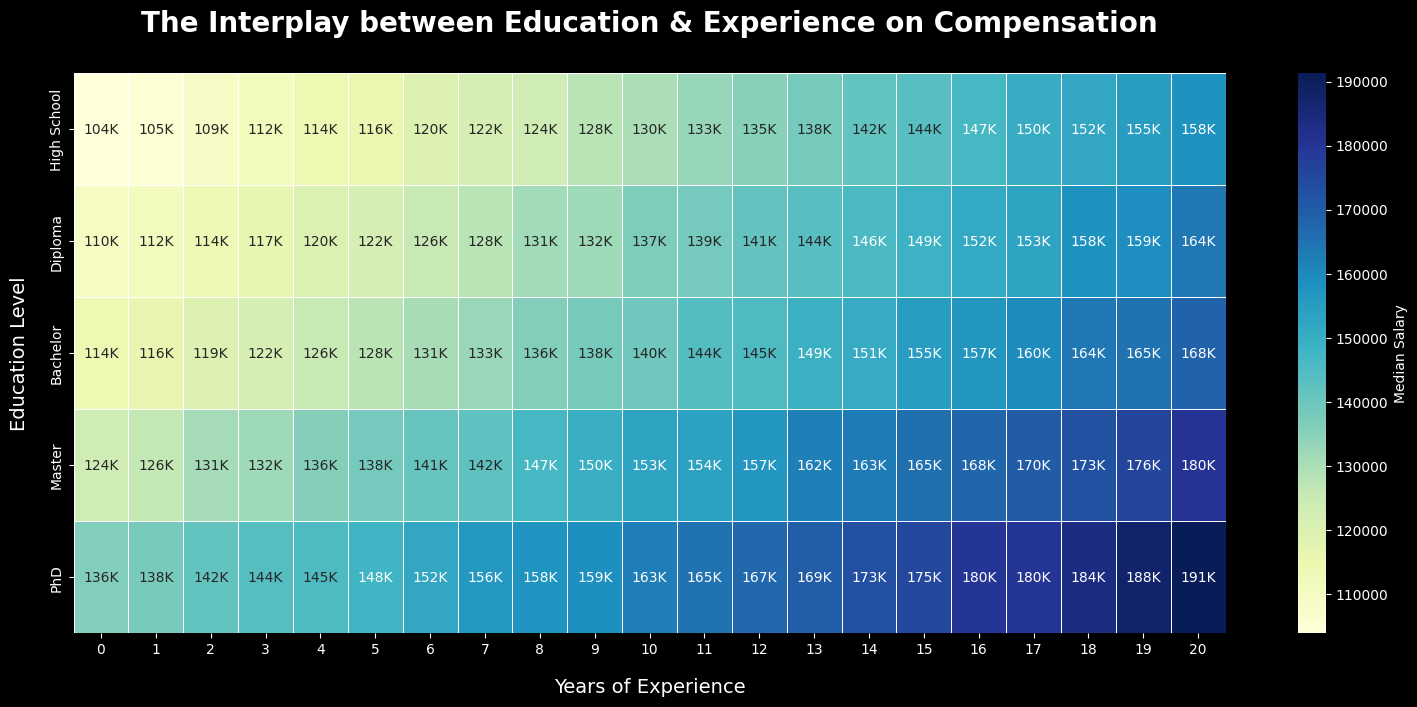

In [30]:

plt.style.use('dark_background')

annot_text = pivot_df.map(lambda x: f'{x/1000:.0f}K' if pd.notnull(x) else '')

fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    pivot_df, 
    annot=annot_text, 
    fmt="", 
    cmap="YlGnBu", 
    linewidths=.5, 
    cbar_kws={'label': 'Median Salary'},
    ax=ax
)

ax.set_title('The Interplay between Education & Experience on Compensation', 
             fontsize=20, fontweight='bold', pad=30)

ax.set_xlabel('Years of Experience', fontsize=14, labelpad=15)
ax.set_ylabel('Education Level', fontsize=14, labelpad=15)

plt.subplots_adjust(top=0.85, bottom=0.15, left=0.15, right=0.95)

plt.show()

**Experience as a Key Factor**

The horizontal color gradient confirms that years of experience consistently contribute to salary growth at all educational levels. Even without a college degree, 20 years of experience can increase a high school graduate's salary by approximately 52% (from $104,000 to $158,000).

**The Trade-off Between Degree and Experience**

The heat map demonstrates that professional experience effectively bridges the salary gap between academic qualifications and academic qualifications. For example, a professional with a bachelor's degree and 10 years of experience earns $140,000 more than someone with a recent master's degree ($124,000–$126,000). This shows that practical experience is highly valued and can compensate for lower academic qualifications over time.

**The “Master’s and PhD Advantage”**

Advanced degrees offer a “better start” and faster career progression. While it takes a bachelor's degree holder twenty years to earn a salary of $168,000, a PhD holder reaches the same level within 12 years of experience.

### II-3. Country-wise Comparison

#### II-3.1. Statistical Summary: Median Salary by Country

In [31]:
country_analysis = df.groupby('location')['salary'].agg(['median', 'count']).sort_values(by='median', ascending=False)
country_analysis

,median,count
location,,
USA,179647.0,24931
Canada,165474.0,25165
UK,158191.0,24927
Germany,151538.0,24763
Sweden,138033.0,25100
Remote,137836.0,25065
Australia,137753.5,25258
Singapore,137699.0,25035
Netherlands,137356.0,24861


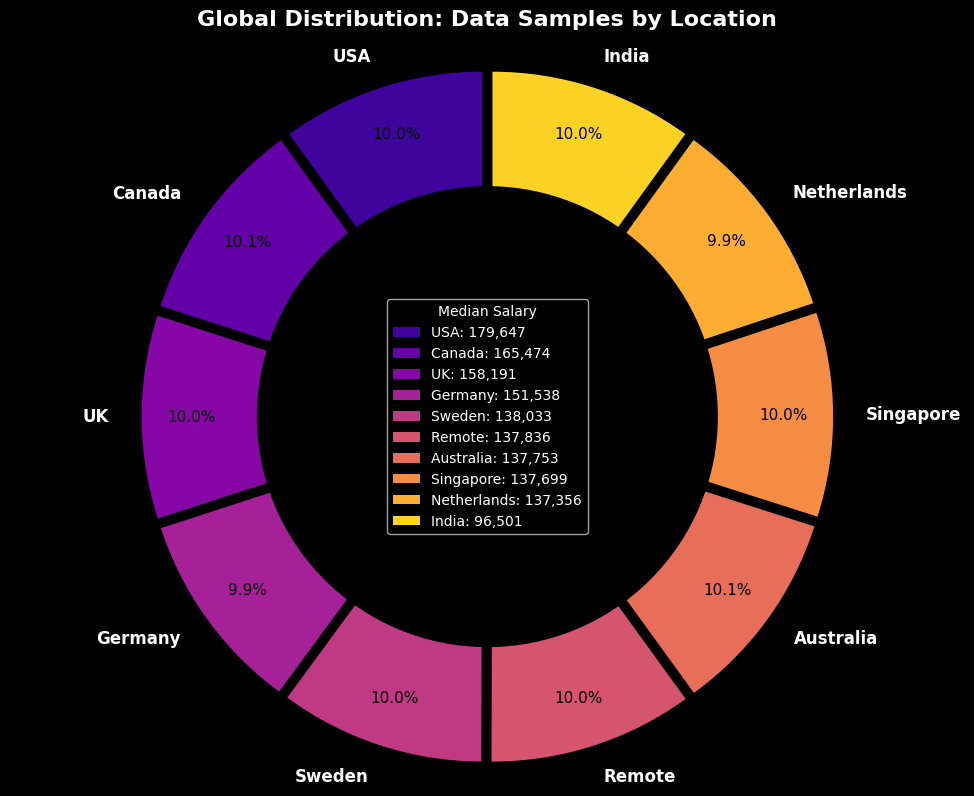

In [34]:

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(country_analysis['count'], 
                                  labels=country_analysis.index,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  colors=sns.color_palette("plasma", len(country_analysis)),
                                  pctdistance=0.85, 
                                  explode=[0.05] * len(country_analysis)) 

centre_circle = plt.Circle((0,0), 0.70, fc='black')
fig.gca().add_artist(centre_circle)

plt.setp(texts, size=12, weight="bold", color="white")
plt.setp(autotexts, size=11, color="black") 

ax.axis('equal') 
plt.title('Global Distribution: Data Samples by Location', fontsize=16, fontweight='bold', pad=20)

salary_info = [f"{loc}: {int(med):,}" for loc, med in zip(country_analysis.index, country_analysis['median'])]
ax.legend(wedges, salary_info, title="Median Salary", loc="center", fontsize=10)

plt.tight_layout()
plt.show()

**A homogeneous distribution: The graph shows a nearly uniform distribution of data samples across all locations (approximately 10% per location).**

**Salary disparities: Despite the equal sample sizes, average salaries vary significantly, with the USA topping the list at 179,647 and India at the bottom at 96,501.**

#### II-3-2. Salary Dispersion: Identifying Income Gaps by Location

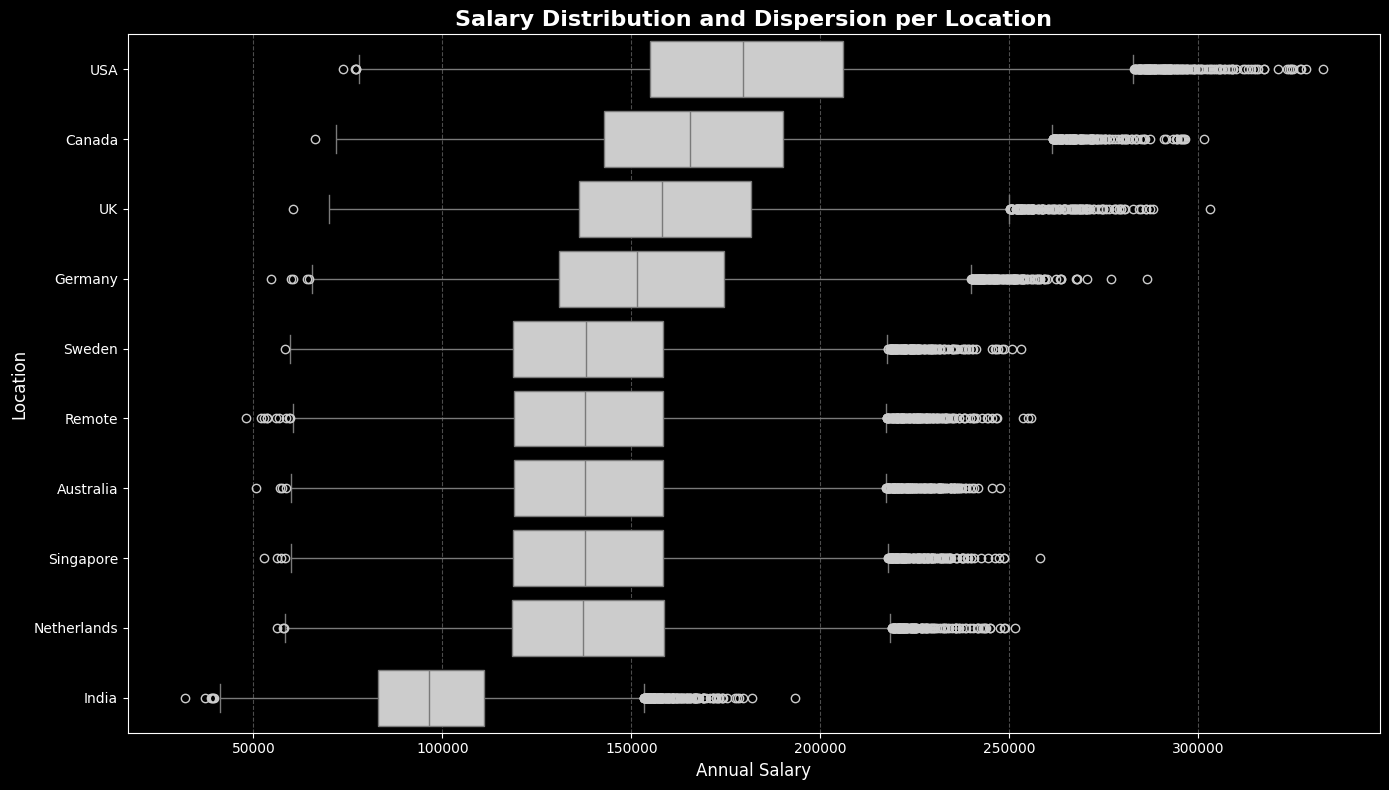

In [45]:
plt.figure(figsize=(14, 8))
plt.style.use('dark_background')

sns.boxplot(x='salary', y='location', data=df, 
            order=country_analysis.index, 
            flierprops={"marker": "o", "markeredgecolor": "#ccc"},
           color="#ccc"           ) 

plt.title('Salary Distribution and Dispersion per Location', fontsize=16, fontweight='bold')
plt.xlabel('Annual Salary', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
stats_table = df.groupby('location')['salary'].agg([
    ('Median', 'median'),
    ('25%', lambda x: x.quantile(0.25)),
    ('75%', lambda x: x.quantile(0.75))
])

stats_table['IQR (Difference)'] = stats_table['75%'] - stats_table['25%']

stats_table = stats_table.sort_values(by='Median', ascending=False)

styled_stats = stats_table.style.format("${:,.0f}")
styled_stats

,Median,25%,75%,IQR (Difference)
location,,,,
USA,"$179,647","$154,842","$206,070","$51,228"
Canada,"$165,474","$142,659","$190,110","$47,451"
UK,"$158,191","$136,178","$181,744","$45,567"
Germany,"$151,538","$130,754","$174,424","$43,670"
Sweden,"$138,033","$118,730","$158,346","$39,616"
Remote,"$137,836","$118,931","$158,410","$39,479"
Australia,"$137,754","$118,978","$158,353","$39,375"
Singapore,"$137,699","$118,626","$158,334","$39,708"
Netherlands,"$137,356","$118,479","$158,621","$40,142"


**Detailed Notes:**

Mechanical Correlation Between Ranges: There is an unusual correlation between the minimum, maximum, and median values. In real-world datasets, a country with a low median might have very high wages (e.g., few high-income earners), but here, no region with a low median exceeds the maximum wage in countries with the highest median. This suggests that the data may be artificially generated and not based on a naturally occurring random sample.

Mirror Effect (Artificial Symmetry): There is a near-perfect and suspiciously similar match between the samples from Sweden, Australia, Singapore, the Outback, and the Netherlands. These four categories are almost identical across five different statistical indicators:

- Minimum and maximum values.

- Meaning.

- 25th and 75th percentiles (quartiles).

This level of mathematical symmetry across diverse geographical locations strongly supports the hypothesis that this dataset may be artificial.

Interquartile Range (IQR) Analysis: * USA: Shows the largest difference between the 75th and 25th percentiles (interquartile range), indicating the most flexible salary distribution in this dataset.

India: Shows the smallest difference (interquartile range), indicating a very narrow salary range that lacks the diversity typical of a real labor market.

Media-Dispersion Relationship: We observe a direct, positive relationship between the median and the interquartile range. As the median increases, the gap between the 75th and 25th percentiles increases proportionally.


#### II-3-3. Data Samples by Education Level

education_level,Bachelor,Diploma,High School,Master,PhD
location,,,,,
Australia,4983,4997,5169,5102,5007
Canada,5025,4997,4952,5160,5031
Germany,4868,4927,5053,4958,4957
India,5109,4922,4932,4956,4976
Netherlands,4912,4922,5041,5009,4977
Remote,4990,4973,4993,5095,5014
Singapore,5069,5053,4935,4996,4982
Sweden,5065,5052,5013,4995,4975
UK,4997,5010,4990,4974,4956


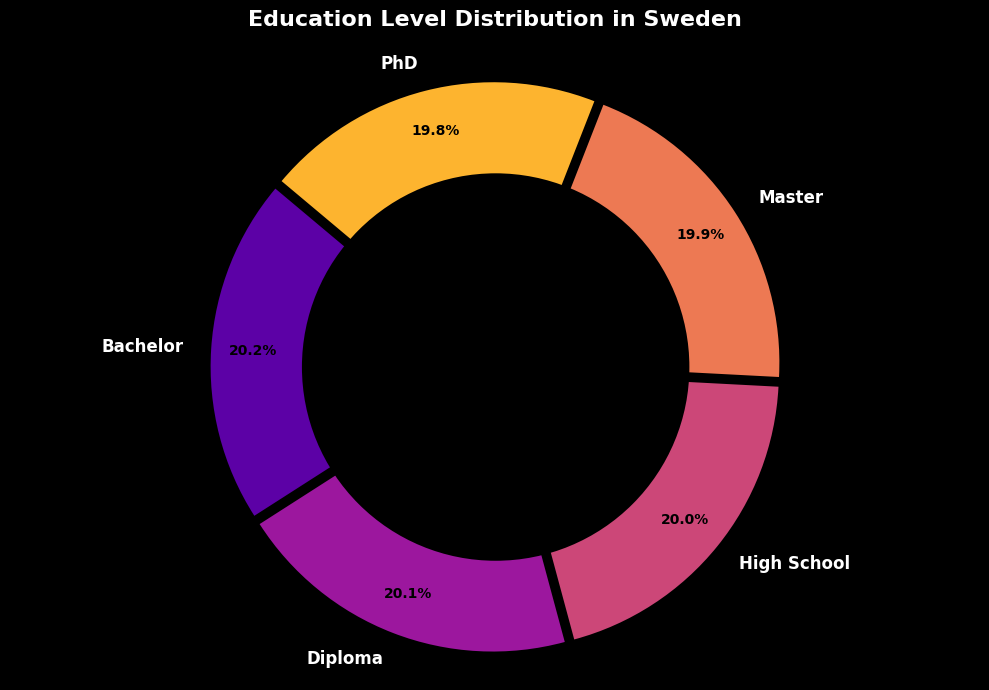

In [55]:
edu_loc_table = pd.crosstab(df['location'], df['education_level'])
display(edu_loc_table)

sweden_data = edu_loc_table.loc['Sweden']

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(sweden_data, 
                                  labels=sweden_data.index,
                                  autopct='%1.1f%%',
                                  startangle=140,
                                  colors=sns.color_palette("plasma", len(sweden_data)),
                                  pctdistance=0.85,
                                  explode=[0.03] * len(sweden_data))

centre_circle = plt.Circle((0,0), 0.70, fc='black')
fig.gca().add_artist(centre_circle)

plt.setp(texts, size=12, weight="bold")
plt.setp(autotexts, size=10, color="black", weight="bold")

plt.title('Education Level Distribution in Sweden', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()
plt.show()

**Observation and Analysis:**

The "Constant Number" Phenomenon: When examining the distribution of educational levels in different geographical locations (such as Sweden, the USA, and India), we observe a remarkable similarity in the number of samples for each category.

The 20% Uniformity Rule: In each country, each educational level (high school, bachelor's degree, etc.) represents approximately 20% of the total sample.

This near-perfect similarity strongly supports the hypothesis of artificial data.

#### II-3-4. Corporate Landscape: Company Size Distribution by Location

company_size,Enterprise,Large,Medium,Small,Startup
location,,,,,
Australia,4988,5050,5108,5135,4977
Canada,5016,4913,5058,5055,5123
Germany,4850,5092,4943,4993,4885
India,5002,4975,4985,4934,4999
Netherlands,5027,4967,5071,4920,4876
Remote,5059,5044,4832,5084,5046
Singapore,4966,5024,5007,5101,4937
Sweden,5080,5085,5037,4948,4950
UK,4973,4973,5043,5061,4877


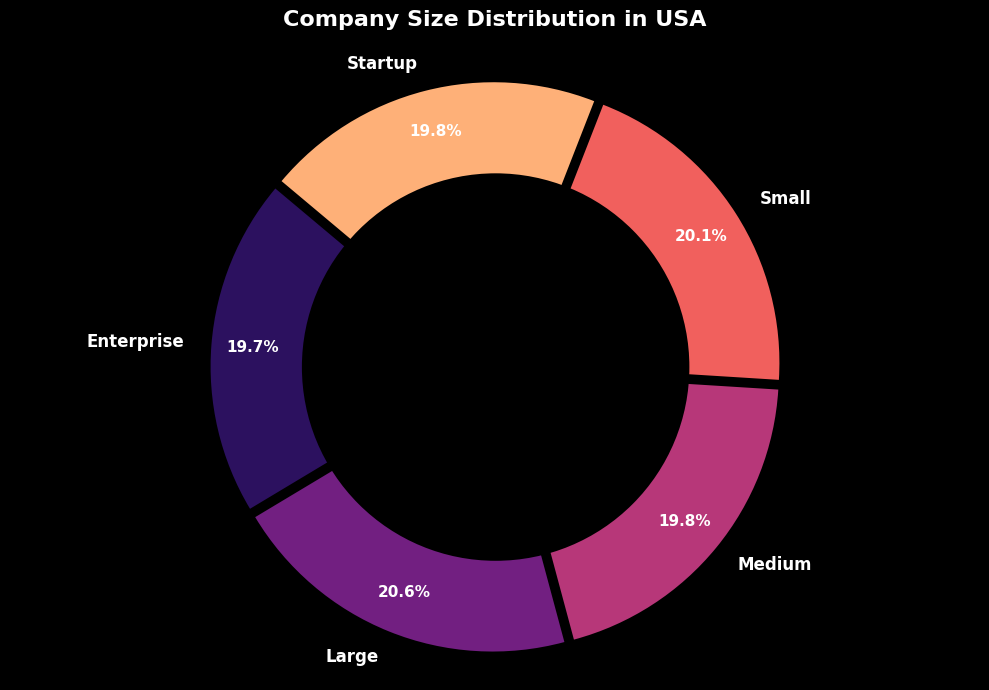

In [58]:
company_loc_table = pd.crosstab(df['location'], df['company_size'])
display(company_loc_table)

usa_company_data = company_loc_table.loc['USA']

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(usa_company_data, 
                                  labels=usa_company_data.index,
                                  autopct='%1.1f%%',
                                  startangle=140,
                                  colors=sns.color_palette("magma", len(usa_company_data)),
                                  pctdistance=0.85,
                                  explode=[0.03] * len(usa_company_data))

centre_circle = plt.Circle((0,0), 0.70, fc='black')
fig.gca().add_artist(centre_circle)

plt.setp(texts, size=12, weight="bold")
plt.setp(autotexts, size=11, color="white", weight="bold")

plt.title('Company Size Distribution in USA', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()
plt.show()

**Observation and Analysis:**

The **"Constant Number"** Phenomenon: When examining the distribution of company sizes in different geographical locations (such as Sweden, the USA, and India), we observe a remarkable similarity in the number of samples for each category.

The 20% Uniformity Rule: In each country, each company size  represents approximately 20% of the total sample.

Conclusion: This near-perfect similarity strongly supports the hypothesis of artificial data.

### II-4. Job title comparison

#### II-4-1. Statistical Summary: Median Salary by Job Title

,median,count
job_title,,
AI Engineer,171674.0,20945
Machine Learning Engineer,160933.0,20677
Product Manager,155655.5,20950
Cloud Engineer,150005.0,20686
DevOps Engineer,148021.0,20889
Cybersecurity Analyst,146737.0,20959
Data Scientist,145231.5,20890
Software Engineer,139432.5,20876
Backend Developer,136678.0,21125


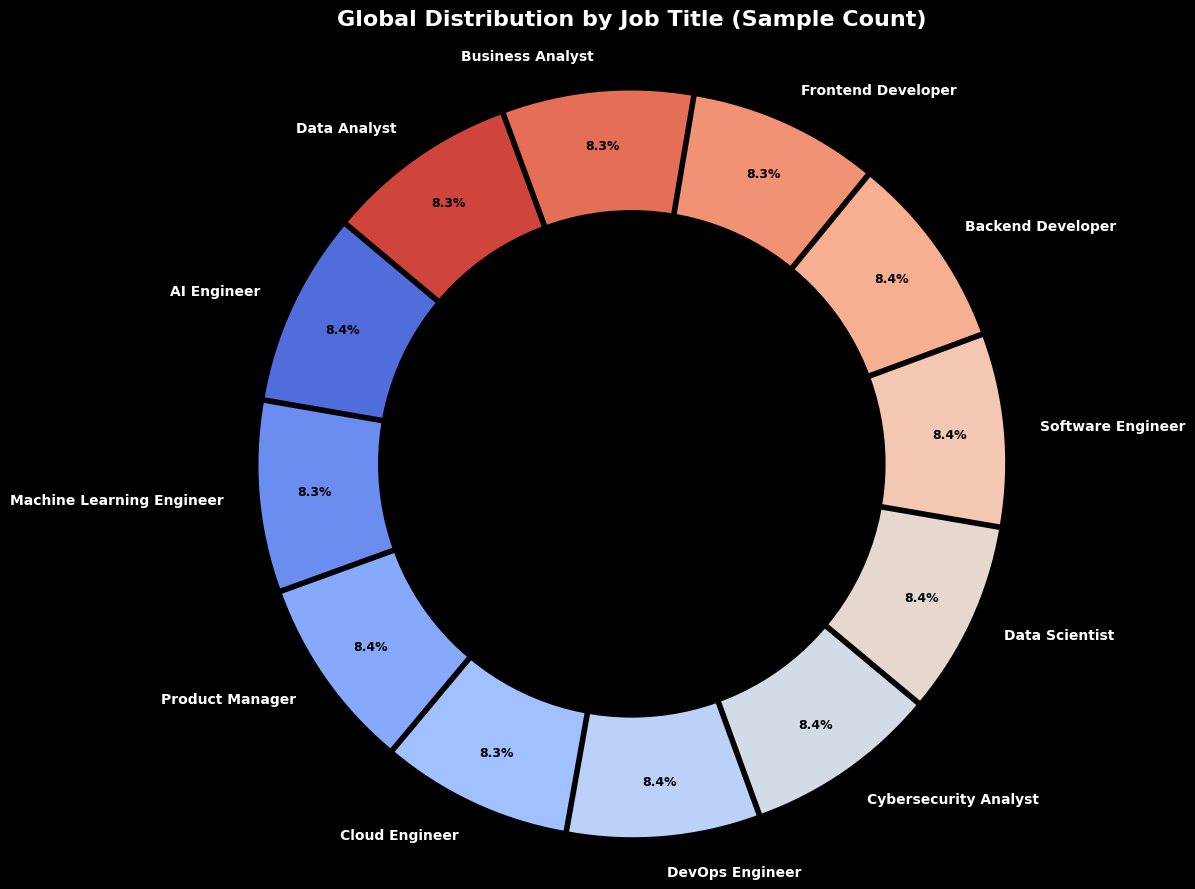

In [59]:
job_stats = df.groupby('job_title')['salary'].agg(['median', 'count']).sort_values(by='median', ascending=False)
display(job_stats)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 9))

wedges, texts, autotexts = ax.pie(job_stats['count'], 
                                  labels=job_stats.index,
                                  autopct='%1.1f%%',
                                  startangle=140,
                                  colors=sns.color_palette("coolwarm", len(job_stats)),
                                  pctdistance=0.85,
                                  explode=[0.03] * len(job_stats))

centre_circle = plt.Circle((0,0), 0.70, fc='black')
fig.gca().add_artist(centre_circle)

plt.setp(texts, size=10, weight="bold")
plt.setp(autotexts, size=9, color="black", weight="bold")

plt.title('Global Distribution by Job Title (Sample Count)', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()
plt.show()

The "Constant Number" Phenomenon: When examining the distribution of the 12 main job titles (such as Data Scientist, ML Engineer, Data Analyst, etc.), we observe a remarkable similarity in the number of samples for each category.

The 8.3% Uniformity Rule: Within the dataset, each of the 12 job titles represents approximately 8.3% of the total sample (100/12≈8.3%). In a real-world labor market.

Conclusion: This near-perfect similarity across 12 distinct categories strongly supports the hypothesis of artificial data.

#### II-4-2. Salary Dispersion: Identifying Income Gaps by Job Title

,min,max,median,IQR
job_title,,,,
AI Engineer,66371,333046,171674.0,49835.00
Machine Learning Engineer,59925,317377,160933.0,48416.00
Product Manager,59796,301294,155655.5,46941.00
Cloud Engineer,45030,292855,150005.0,46491.00
DevOps Engineer,54985,304968,148021.0,46239.00
Cybersecurity Analyst,54224,303178,146737.0,45272.50
Data Scientist,51349,288049,145231.5,45421.50
Software Engineer,51313,284442,139432.5,45240.25
Backend Developer,46304,290512,136678.0,44613.00


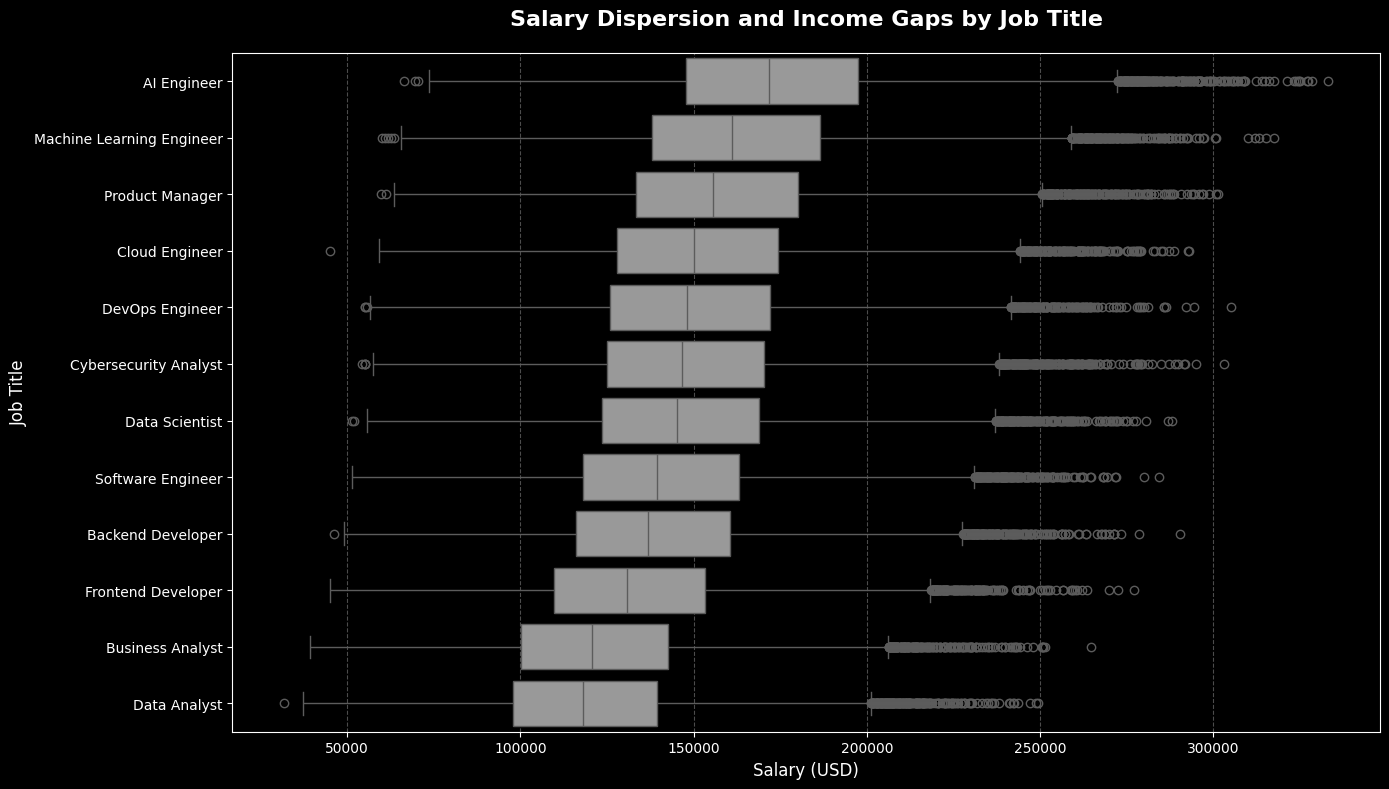

In [67]:
job_dispersion = df.groupby('job_title')['salary'].agg(['min', 'max', 'median', lambda x: x.quantile(0.75) - x.quantile(0.25)]).rename(columns={'<lambda_0>': 'IQR'}).sort_values(by='median', ascending=False)
display(job_dispersion)

plt.style.use('dark_background')
plt.figure(figsize=(14, 8))

sns.boxplot(x='salary', y='job_title', data=df, order=job_dispersion.index,color="#999")

plt.title('Salary Dispersion and Income Gaps by Job Title', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Salary (USD)', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
job_salary_stats = df.groupby('job_title')['salary'].agg([
    ('Median', 'median'),
    ('25%', lambda x: x.quantile(0.25)),
    ('75%', lambda x: x.quantile(0.75)),
    ('IQR (75%-25%)', lambda x: x.quantile(0.75) - x.quantile(0.25))
]).sort_values(by='Median', ascending=False)

display(job_salary_stats)

,Median,25%,75%,IQR (75%-25%)
job_title,,,,
AI Engineer,171674.0,147656.00,197491.00,49835.00
Machine Learning Engineer,160933.0,138044.00,186460.00,48416.00
Product Manager,155655.5,133200.75,180141.75,46941.00
Cloud Engineer,150005.0,127965.00,174456.00,46491.00
DevOps Engineer,148021.0,125860.00,172099.00,46239.00
Cybersecurity Analyst,146737.0,124981.00,170253.50,45272.50
Data Scientist,145231.5,123540.75,168962.25,45421.50
Software Engineer,139432.5,117949.75,163190.00,45240.25
Backend Developer,136678.0,115936.00,160549.00,44613.00


**Observation and Analysis:**

Linear range progression: We observe a strikingly consistent correlation, where the minimum and maximum salary thresholds rise in direct proportion to the median. In a typical job market, some jobs (such as data analyst) might have a high maximum salary due to the presence of experienced candidates, even though the median is low. However, in this case, the entire range moves as a single, fixed unit.

Relative dispersion (interquartile range): There is a clear and consistent relationship between the median and the interquartile range (75% - 25%). As the average salary for a given job increases, the gap between the 25th and 75th percentiles widens at a constant rate.